In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

Saving swiggy_data.xlsx to swiggy_data (1).xlsx


In [ ]:
df = pd.read_excel('swiggy_data.xlsx')

In [ ]:
df = df.copy()

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [ ]:
print("\nShape:", df.shape)

print("\nColumns:")
df.columns

print("\nInfo:")
df.info()


Shape: (197430, 10)

Columns:

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [ ]:
df.isnull().sum()

,0
State,0
City,0
Order Date,0
Restaurant Name,0
Location,0
Category,0
Dish Name,0
Price (INR),0
Rating,0
Rating Count,0


In [ ]:
df = df.drop_duplicates().copy()

In [ ]:
df.shape

(197403, 10)

In [ ]:
df.loc[:, 'Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

In [ ]:
df.loc[:, 'Month'] = df['Order Date'].dt.month_name()

In [ ]:
df[['Order Date','Month']].head()

,Order Date,Month
0,2025-06-29,June
1,2025-04-03,April
2,2025-01-15,January
3,2025-04-17,April
4,2025-03-13,March


In [ ]:
print("\nTotal Records:", len(df))
print("Total Cities:", df['City'].nunique())
print("Total Restaurants:", df['Restaurant Name'].nunique())
print("Total Categories:", df['Category'].nunique())


Total Records: 197403
Total Cities: 28
Total Restaurants: 993
Total Categories: 4972


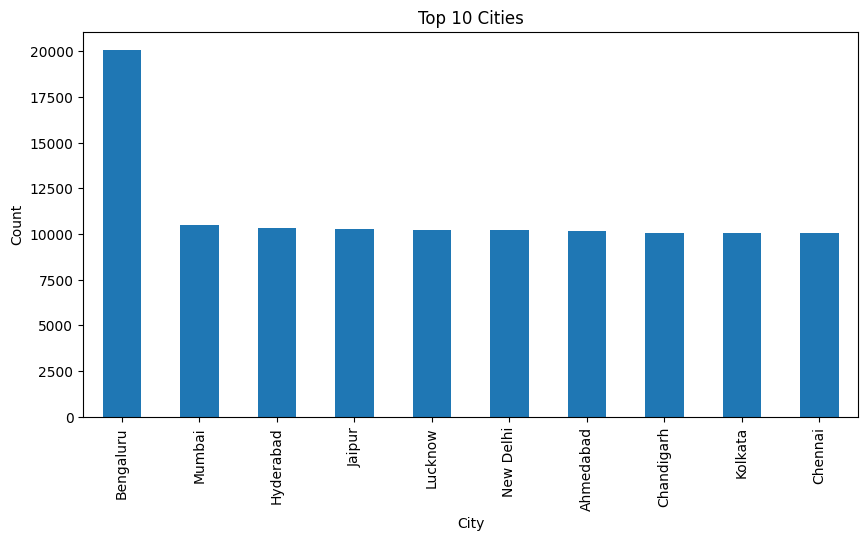

In [66]:
city_count = df['City'].value_counts().head(10)

city_count.plot(kind='bar')

plt.title("Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Count")

plt.show()

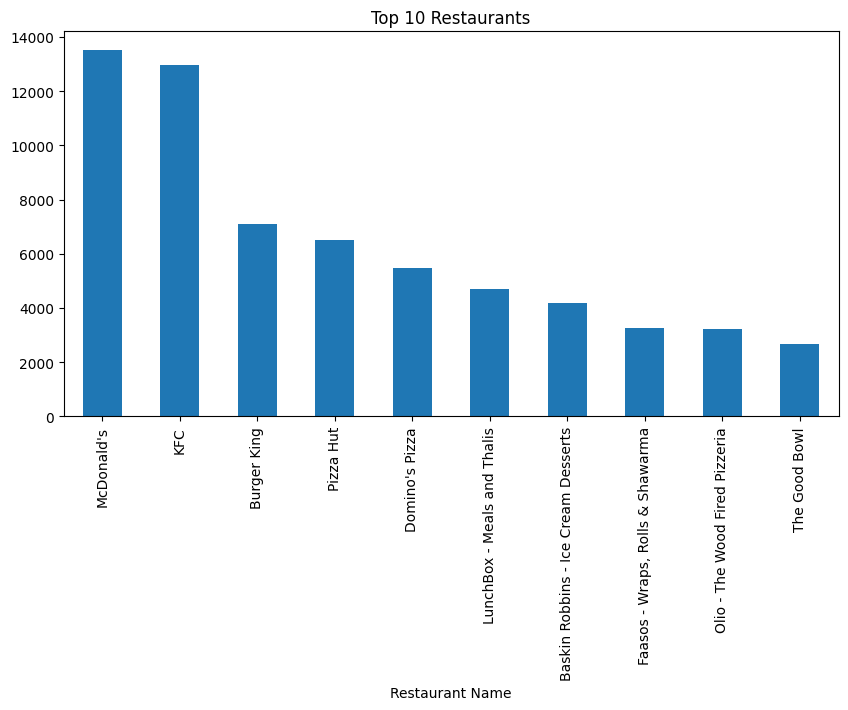

In [ ]:
top_restaurants = df['Restaurant Name'].value_counts().head(10)

top_restaurants.plot(kind='bar')

plt.title("Top 10 Restaurants")
plt.show()

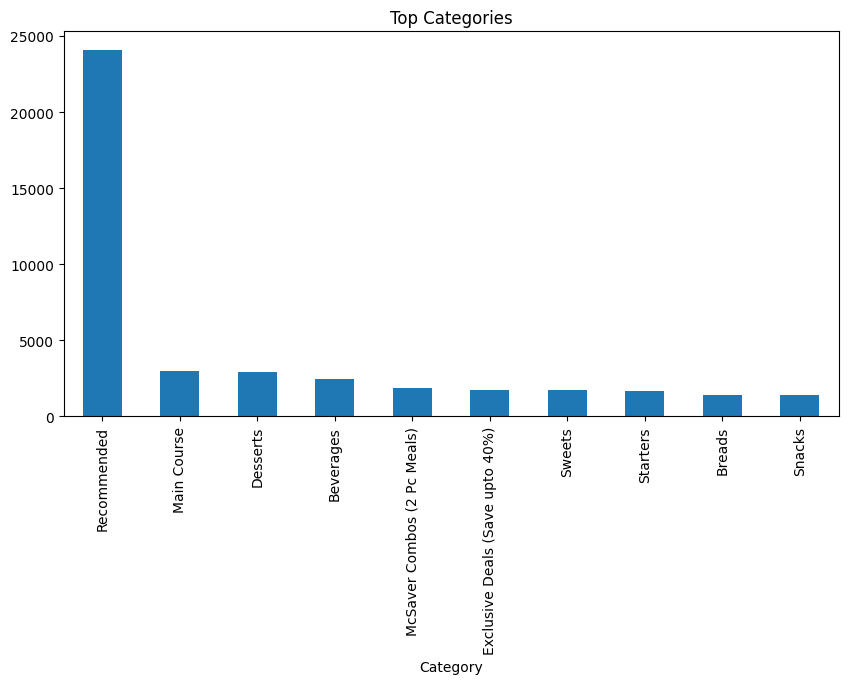

In [ ]:
top_categories = df['Category'].value_counts().head(10)

top_categories.plot(kind='bar')

plt.title("Top Categories")
plt.show()

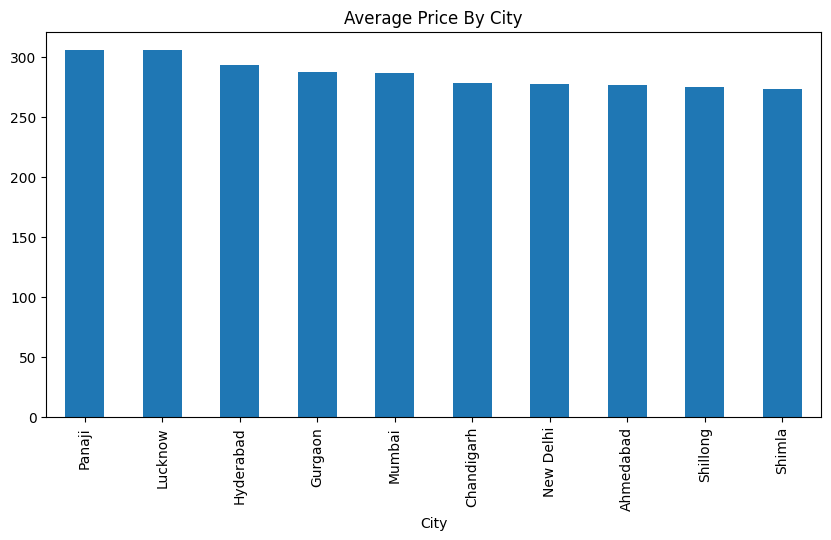

In [ ]:
avg_price_city = df.groupby('City')['Price (INR)'].mean().sort_values(ascending=False).head(10)

avg_price_city.plot(kind='bar')

plt.title("Average Price By City")
plt.show()

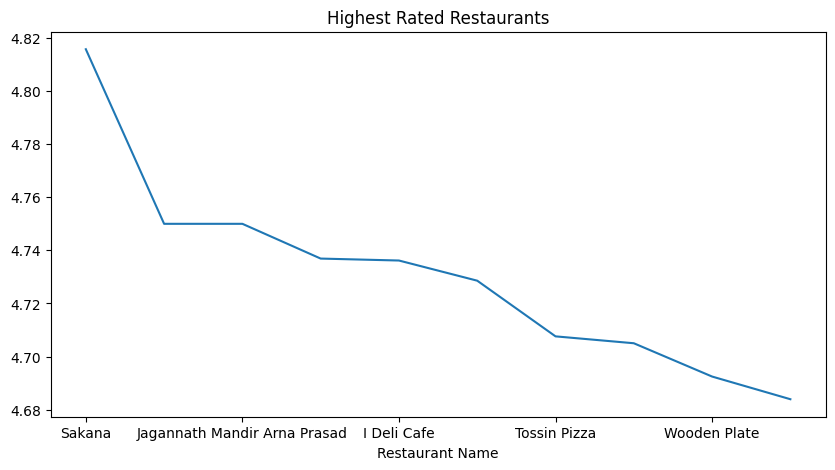

In [ ]:
top_rated = df.groupby('Restaurant Name')['Rating'].mean().sort_values(ascending=False).head(10)

top_rated.plot(kind='line')

plt.title("Highest Rated Restaurants")
plt.show()

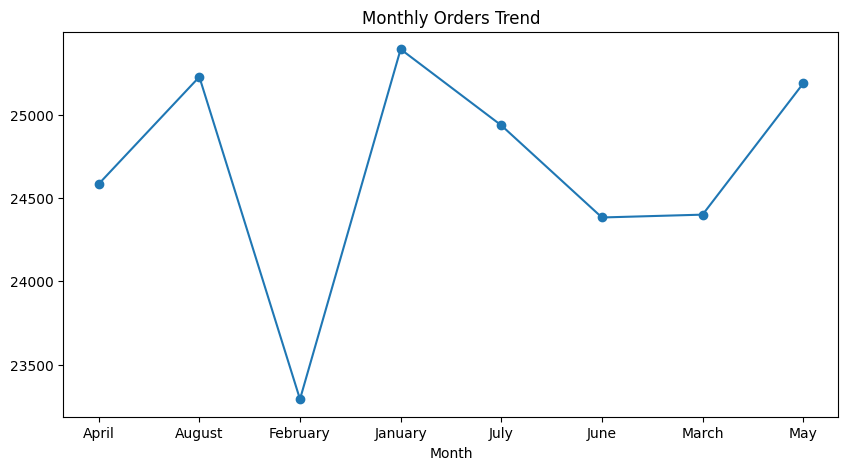

In [ ]:
monthly_orders = df.groupby('Month').size()

monthly_orders.plot(kind='line', marker='o')

plt.title("Monthly Orders Trend")
plt.show()

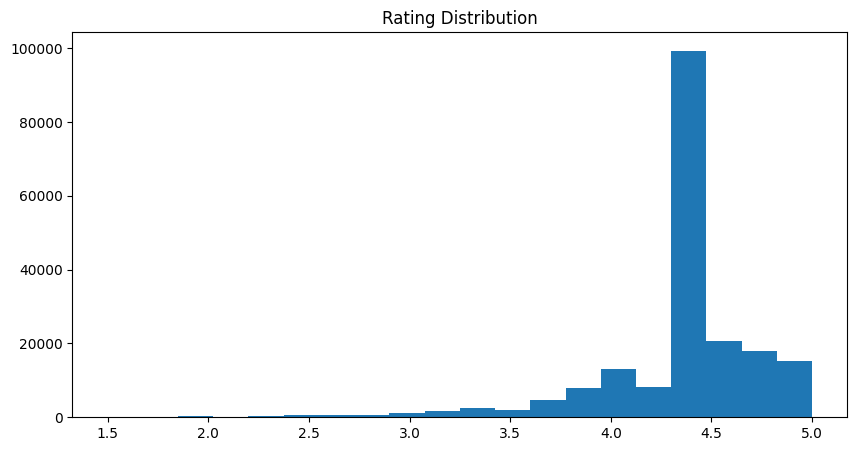

In [ ]:
plt.hist(df['Rating'], bins=20)

plt.title("Rating Distribution")

plt.show()

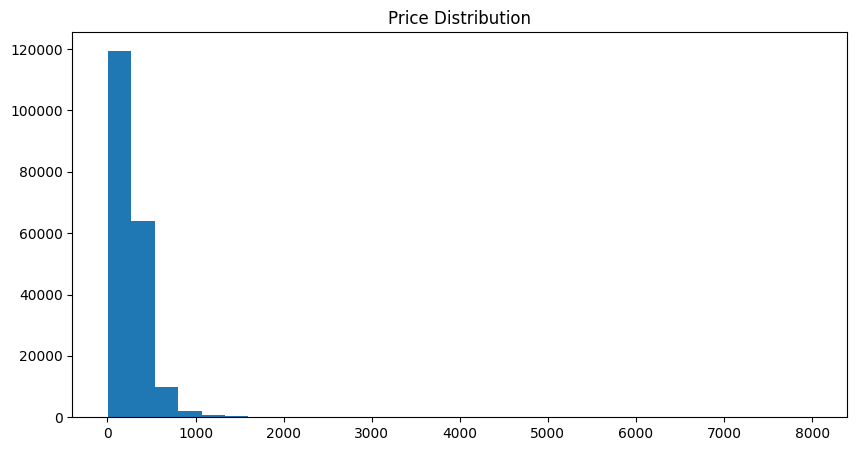

In [ ]:
plt.hist(df['Price (INR)'], bins=30)

plt.title("Price Distribution")

plt.show()

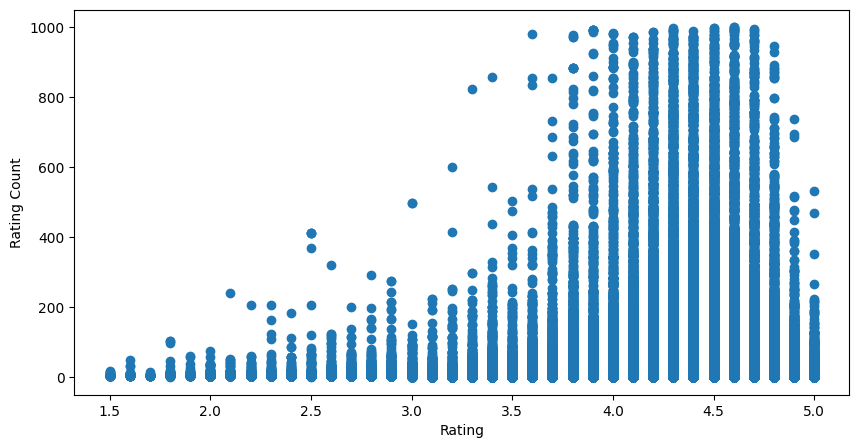

In [ ]:
plt.scatter(df['Rating'], df['Rating Count'])

plt.xlabel("Rating")
plt.ylabel("Rating Count")

plt.show()

In [ ]:
print(df['City'].value_counts().head(5))

print(df['Category'].value_counts().head(5))

print(df.groupby('Restaurant Name')
['Rating'].mean().sort_values
(ascending=False).head(5))

City
Bengaluru    20072
Mumbai       10507
Hyderabad    10309
Jaipur       10285
Lucknow      10192
Name: count, dtype: int64
Category
Recommended                    24098
Main Course                     2959
Desserts                        2943
Beverages                       2464
McSaver Combos (2 Pc Meals)     1884
Name: count, dtype: int64
Restaurant Name
Sakana                           4.815789
Vijay Dairy                      4.750000
Jagannath Mandir Arna Prasad     4.750000
Radhey Lal's Parampara Sweets    4.736905
I Deli Cafe                      4.736170
Name: Rating, dtype: float64


In [ ]:
print("Average Price:", round(df['Price (INR)'].mean(),2))

Average Price: 268.5


Category
PARTY SPECIALS                     5520.833333
Party Menu for 10pax               4299.000000
56 Bhog                            2739.000000
Chef's Special Assorted Platter    2552.000000
Celebration Box                    2376.000000
Hampers & Gift Boxes               2270.769231
Family Meal Box (serves 4 To 6)    2115.666667
Mega Momos Platter                 2091.500000
3D Customised Cake                 2089.000000
Biryani Bucket [Serves 4-6]        2049.000000
Name: Price (INR), dtype: float64


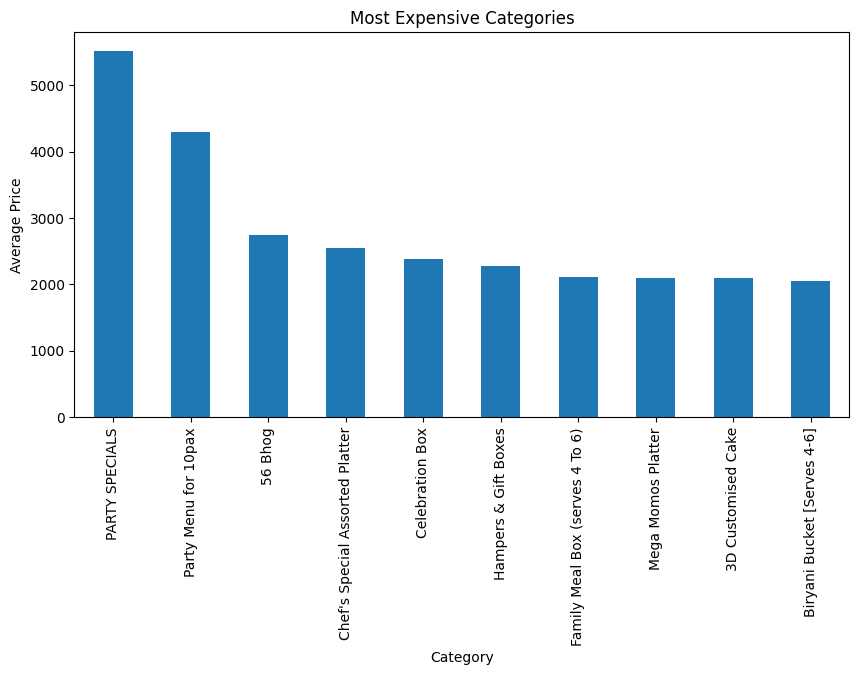

In [ ]:
expensive_cat = df.groupby('Category')['Price (INR)'].mean()

expensive_cat = expensive_cat.sort_values(ascending=False).head(10)

print(expensive_cat)

expensive_cat.plot(kind='bar')

plt.title("Most Expensive Categories")
plt.ylabel("Average Price")
plt.show()

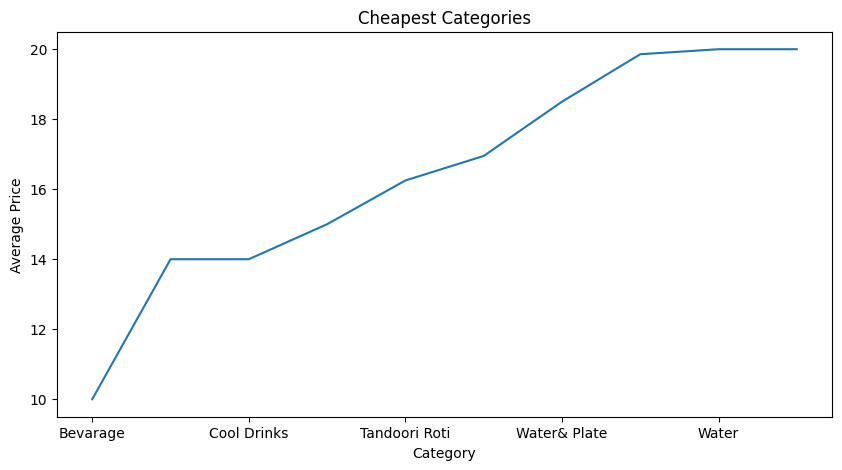

In [ ]:
cheap_cat = df.groupby('Category')['Price (INR)'].mean()

cheap_cat = cheap_cat.sort_values().head(10)

cheap_cat.plot(kind='line')

plt.title("Cheapest Categories")
plt.ylabel("Average Price")
plt.show()

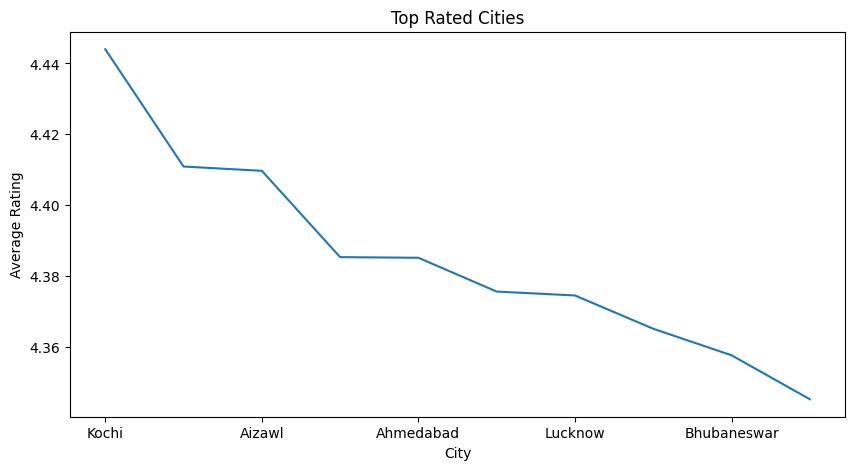

In [ ]:
city_rating = df.groupby('City')['Rating'].mean()

city_rating = city_rating.sort_values(ascending=False).head(10)

city_rating.plot(kind='line')

plt.title("Top Rated Cities")
plt.ylabel("Average Rating")
plt.show()

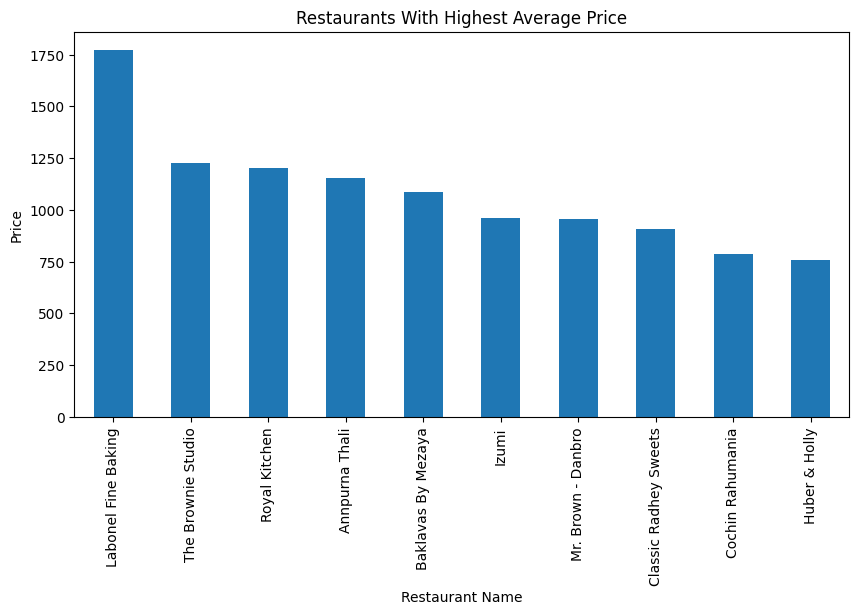

In [ ]:
restaurant_price = df.groupby('Restaurant Name')['Price (INR)'].mean()

restaurant_price = restaurant_price.sort_values(ascending=False).head(10)

restaurant_price.plot(kind='bar')

plt.title("Restaurants With Highest Average Price")
plt.ylabel("Price")
plt.show()

In [ ]:
df[['Price (INR)','Rating','Rating Count']].corr()

,Price (INR),Rating,Rating Count
Price (INR),1.000000,0.029411,-0.101282
Rating,0.029411,1.000000,0.016161
Rating Count,-0.101282,0.016161,1.000000


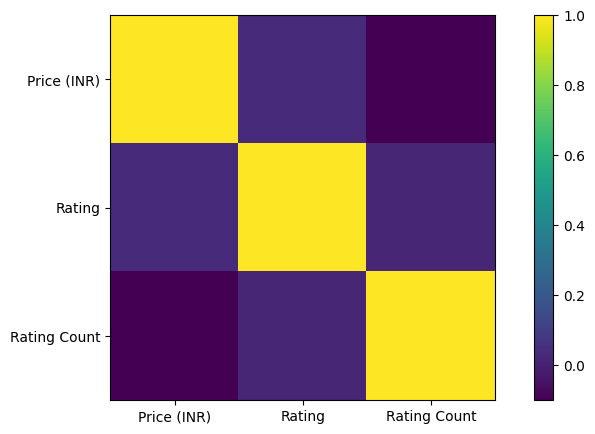

In [ ]:
corr = df[['Price (INR)','Rating','Rating Count']].corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

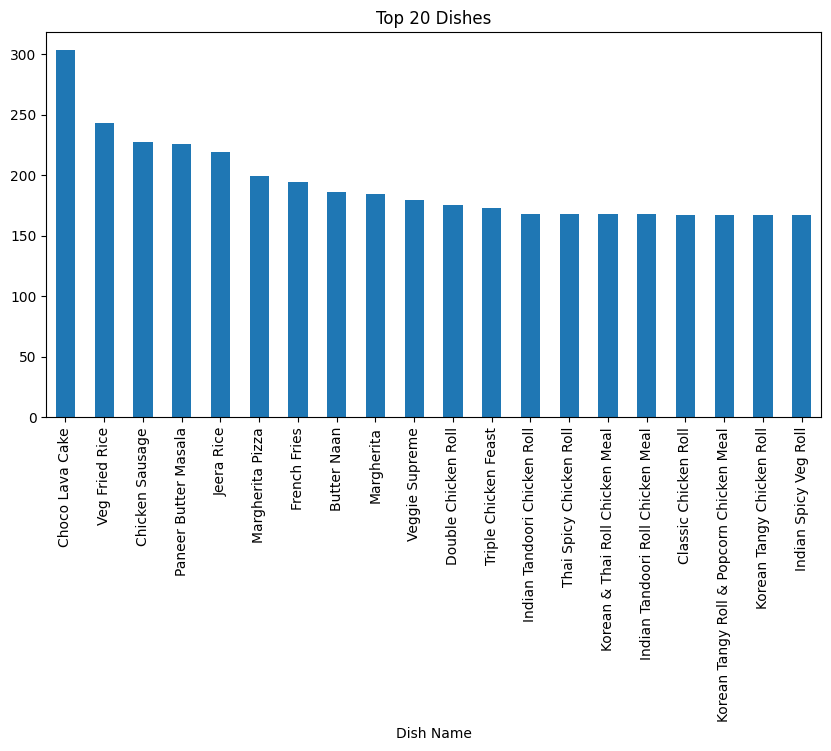

In [ ]:
top_dishes = df['Dish Name'].value_counts().head(20)

top_dishes.plot(kind='bar')

plt.title("Top 20 Dishes")

plt.show()

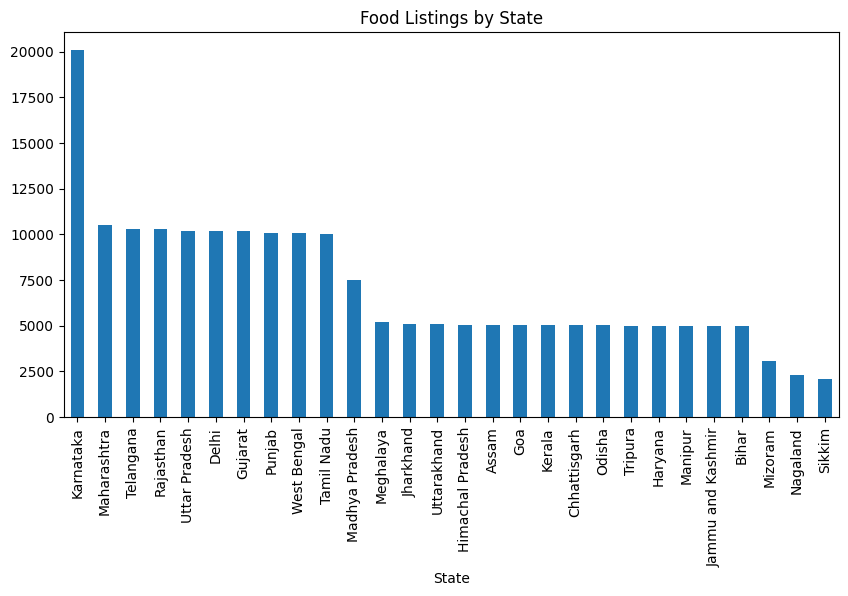

In [ ]:
state_count = df['State'].value_counts()

state_count.plot(kind='bar')

plt.title("Food Listings by State")

plt.show()

In [ ]:
premium = df[df['Price (INR)'] > 500]

print("Premium Dishes:", len(premium))

Premium Dishes: 15500


In [ ]:
premium['Restaurant Name'].value_counts().head(10)

,count
Restaurant Name,
KFC,2347
Pizza Hut,1051
Domino's Pizza,873
McDonald's,531
Veg Darbar by Behrouz Biryani,451
Olio - The Wood Fired Pizzeria,324
Theobroma,302
Oven Story Pizza,279
ITC Master Chef Creations,257


In [ ]:
budget = df[df['Price (INR)'] < 150]

print("Budget Dishes:", len(budget))

Budget Dishes: 54190


In [ ]:
summary = pd.DataFrame({
    'Metric':[
        'Total Records',
        'Total Cities',
        'Total Restaurants',
        'Total Categories',
        'Average Price'
    ],
    'Value':[
        len(df),
        df['City'].nunique(),
        df['Restaurant Name'].nunique(),
        df['Category'].nunique(),
        round(df['Price (INR)'].mean(),2)
    ]
})

summary

,Metric,Value
0,Total Records,197403.0
1,Total Cities,28.0
2,Total Restaurants,993.0
3,Total Categories,4972.0
4,Average Price,268.5
